In [2]:
import pickle

with open('rnamigos1_swap/plot_data/rnamigos1_decoyfinder_rank_percentiles.pkl', 'rb') as f:
    decoyfinder_rank_percentiles = pickle.load(f)

with open('rnamigos1_swap/plot_data/rnamigos1_pdbligand_rank_percentiles.pkl', 'rb') as f:
    pdbligand_rank_percentiles = pickle.load(f)

with open('rnamigos1_swap/plot_data/rnamigos1_noaug_decoyfinder_rank_percentiles.pkl', 'rb') as f:
    noaug_decoyfinder_rank_percentiles = pickle.load(f)

with open('rnamigos1_swap/plot_data/rnamigos1_noaug_pdbligand_rank_percentiles.pkl', 'rb') as f:
    noaug_pdbligand_rank_percentiles = pickle.load(f)

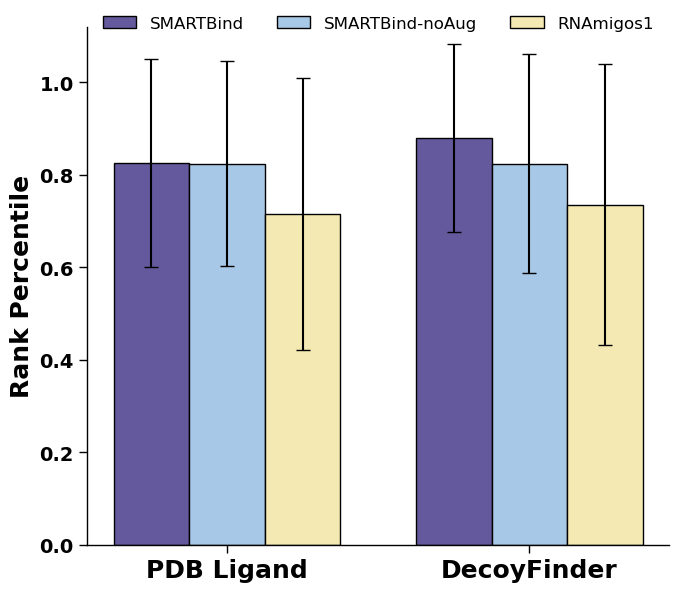

SMARTBind mean +- STD:
  PDB Ligand: 0.826 +- 0.226
  DecoyFinder: 0.879 +- 0.204
SMARTBind-noAug mean +- STD:
  PDB Ligand: 0.824 +- 0.222
  DecoyFinder: 0.824 +- 0.236


In [12]:
import matplotlib.pyplot as plt
import numpy as np

datasets = ['PDB Ligand', 'DecoyFinder']


def std_dev(values):
    arr = np.asarray(values, dtype=float)
    if arr.size <= 1:
        return 0.0
    return float(np.std(arr, ddof=1))


# Compute means and STD from detailed values loaded in Cell 1.
smartbind_raw = [pdbligand_rank_percentiles, decoyfinder_rank_percentiles]
smartbind_noaug_raw = [noaug_pdbligand_rank_percentiles, noaug_decoyfinder_rank_percentiles]

smartbind_values = [float(np.mean(v)) for v in smartbind_raw]
smartbind_noAug_values = [float(np.mean(v)) for v in smartbind_noaug_raw]

smartbind_std = [std_dev(v) for v in smartbind_raw]
smartbind_noAug_std = [std_dev(v) for v in smartbind_noaug_raw]

rnamigos1_values = [0.715, 0.735]
rnamigos1_std = [0.294, 0.304]

# smartbind_color = '#7FCDCD'
smartbind_noAug_color = '#A8C8E8'
# rnamigos1_color = '#B8D4A8'
smartbind_color = '#64599C'
rnamigos1_color = '#F4E9B3'

fig, ax = plt.subplots(figsize=(7, 6))

x = np.arange(len(datasets))
width = 0.25

bars1 = ax.bar(
    x - width,
    smartbind_values,
    width,
    label='SMARTBind',
    color=smartbind_color,
    edgecolor='black',
    linewidth=1,
    yerr=smartbind_std,
    capsize=5,
    ecolor='black'
)
bars2 = ax.bar(
    x,
    smartbind_noAug_values,
    width,
    label='SMARTBind-noAug',
    color=smartbind_noAug_color,
    edgecolor='black',
    linewidth=1,
    yerr=smartbind_noAug_std,
    capsize=5,
    ecolor='black'
)
bars3 = ax.bar(
    x + width,
    rnamigos1_values,
    width,
    label='RNAmigos1',
    color=rnamigos1_color,
    edgecolor='black',
    linewidth=1,
    yerr=rnamigos1_std,
    capsize=5,
    ecolor='black'
)

ax.set_ylim(0.0, 1.12)
ax.set_yticks(np.arange(0.0, 1.09, 0.2))
ax.set_ylabel('Rank Percentile', fontsize=18, fontweight='bold')
ax.tick_params(axis='y', labelsize=14, width=1, length=6)
ax.tick_params(axis='x', labelsize=18, width=1, length=6)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')

ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=18, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_linewidth(1)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_linewidth(1)
ax.spines['bottom'].set_color('black')

ax.grid(False)

ax.legend(loc='upper center', fontsize=12, frameon=False, ncol=3, bbox_to_anchor=(0.5, 1.05))

plt.tight_layout()
plt.savefig('rnamigos1_benchmark.png', dpi=600, bbox_inches='tight')
plt.savefig('rnamigos1_benchmark.pdf', bbox_inches='tight')
plt.show()

print('SMARTBind mean +- STD:')
for i, (val, std) in enumerate(zip(smartbind_values, smartbind_std)):
    print(f'  {datasets[i]}: {val:.3f} +- {std:.3f}')

print('SMARTBind-noAug mean +- STD:')
for i, (val, std) in enumerate(zip(smartbind_noAug_values, smartbind_noAug_std)):
    print(f'  {datasets[i]}: {val:.3f} +- {std:.3f}')

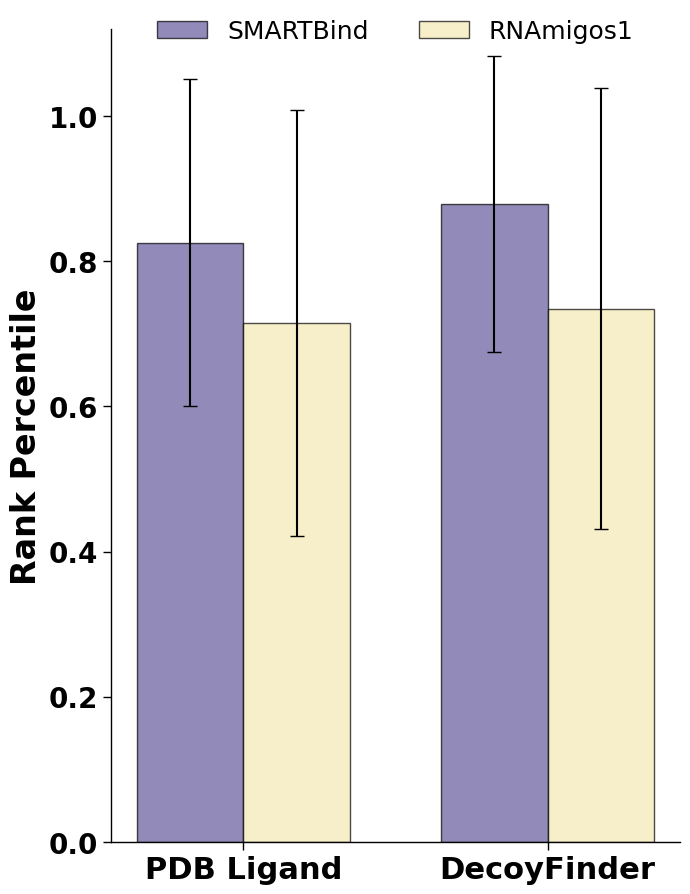

SMARTBind mean +- STD:
  PDB Ligand: 0.826 +- 0.226
  DecoyFinder: 0.879 +- 0.204
RNAmigos1 mean +- STD:
  PDB Ligand: 0.715 +- 0.294
  DecoyFinder: 0.735 +- 0.304


In [11]:
import matplotlib.pyplot as plt
import numpy as np

datasets = ['PDB Ligand', 'DecoyFinder']


def std_dev(values):
    arr = np.asarray(values, dtype=float)
    if arr.size <= 1:
        return 0.0
    return float(np.std(arr, ddof=1))


smartbind_raw = [pdbligand_rank_percentiles, decoyfinder_rank_percentiles]
smartbind_values = [float(np.mean(v)) for v in smartbind_raw]
smartbind_std = [std_dev(v) for v in smartbind_raw]

rnamigos1_values = [0.715, 0.735]
rnamigos1_std = [0.294, 0.304]

smartbind_color = '#64599C'
rnamigos1_color = '#F4E9B3'

fig, ax = plt.subplots(figsize=(7, 9))

x = np.arange(len(datasets))
width = 0.35

bars1 = ax.bar(
    x - width / 2,
    smartbind_values,
    width,
    label='SMARTBind',
    color=smartbind_color,
    alpha=0.7,
    edgecolor='black',
    linewidth=1,
    yerr=smartbind_std,
    capsize=5,
    ecolor='black'
)
bars3 = ax.bar(
    x + width / 2,
    rnamigos1_values,
    width,
    label='RNAmigos1',
    color=rnamigos1_color,
    alpha=0.7,
    edgecolor='black',
    linewidth=1,
    yerr=rnamigos1_std,
    capsize=5,
    ecolor='black'
)

ax.set_ylim(0.0, 1.12)
ax.set_yticks(np.arange(0.0, 1.07, 0.2))
ax.set_ylabel('Rank Percentile', fontsize=24, fontweight='bold')
ax.tick_params(axis='y', labelsize=20, width=1, length=6)
ax.tick_params(axis='x', labelsize=20, width=1, length=6)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')

ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=22, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_linewidth(1)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_linewidth(1)
ax.spines['bottom'].set_color('black')

ax.grid(False)

ax.legend(loc='upper center', fontsize=18, frameon=False, ncol=2, bbox_to_anchor=(0.5, 1.04))

plt.tight_layout()
plt.savefig('rnamigos1_benchmark_fig2.png', dpi=600, bbox_inches='tight')
plt.savefig('rnamigos1_benchmark_fig2.pdf', bbox_inches='tight')
plt.show()

print('SMARTBind mean +- STD:')
for i, (val, std) in enumerate(zip(smartbind_values, smartbind_std)):
    print(f'  {datasets[i]}: {val:.3f} +- {std:.3f}')

print('RNAmigos1 mean +- STD:')
for i, (val, std) in enumerate(zip(rnamigos1_values, rnamigos1_std)):
    print(f'  {datasets[i]}: {val:.3f} +- {std:.3f}')